# 2 · Pre-processing: ODTWCHE contrast enhancement

MRI images often have low contrast, which makes tumour edges hard to see. The paper's first phase improves contrast with
**ODTWCHE** (Otsu Double Threshold Weighted Constrained Histogram Equalization):

1. **Otsu double threshold**: split the histogram into 3 parts (dark background, brain tissue, bright regions)
2. **Weighted constraint**: reduce the influence of very frequent grey levels so the image isn't over-enhanced
3. **PSO** (particle swarm optimisation): search for the weights that give the most detail (maximum entropy)
4. **Histogram equalisation** of each part separately
5. **Adaptive gamma correction**: brighten dark areas
6. **Wiener filter**: remove noise

Code: `src/odtwche.py`

In [1]:
import sys
sys.path.append("..")          # so we can import the src/ folder

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from src import config as C
from src.odtwche import odtwche, histogram, entropy, psnr, enhance_dataset

data = pd.read_csv(C.SPLITS_DIR / "dataset.csv")

C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step by step on one image

Otsu thresholds: (44, 115)    PSO weights: [0.1  0.14 0.1 ]


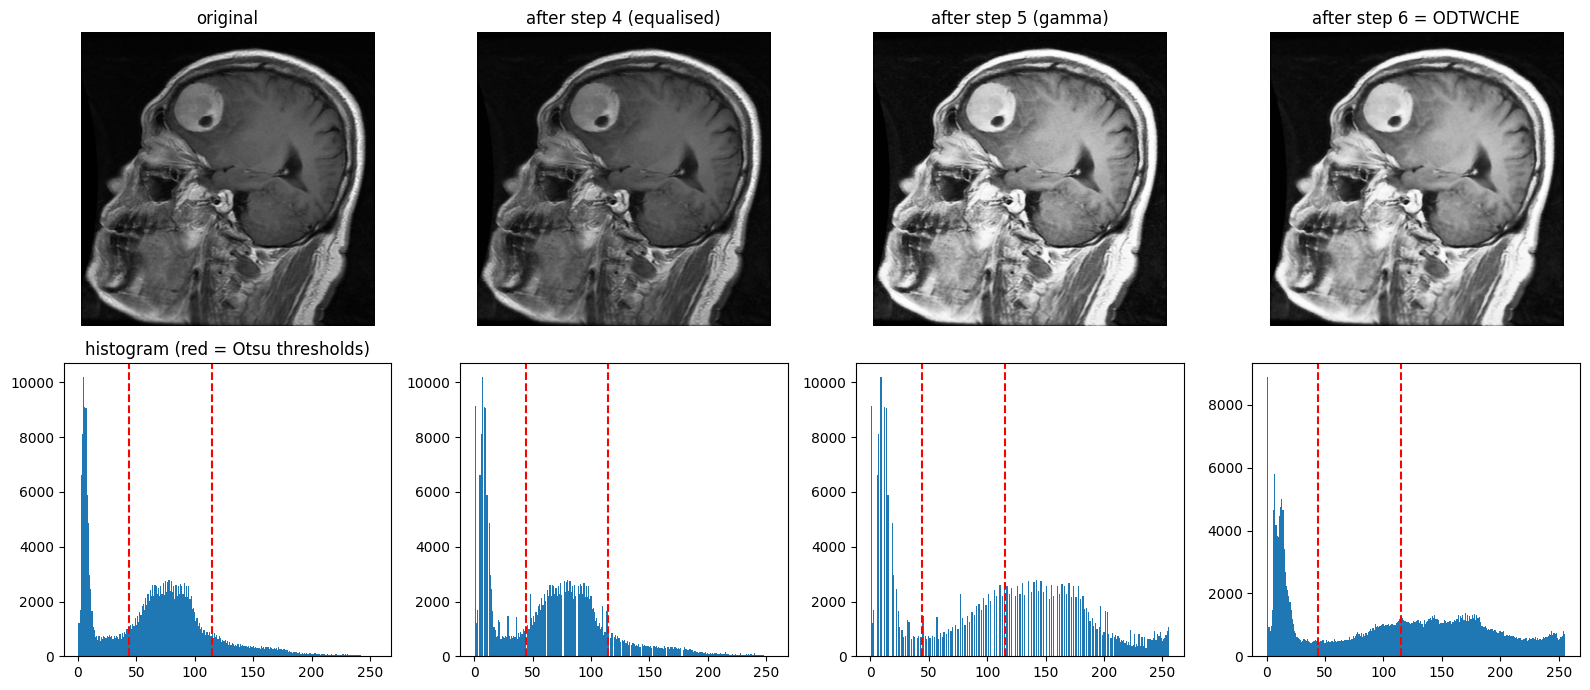

In [2]:
img = cv2.imread(str(C.IMAGES_DIR / data.file.iloc[0]), 0)
enhanced, steps = odtwche(img, return_steps=True)
t1, t2 = steps["thresholds"]
print("Otsu thresholds:", (t1, t2), "   PSO weights:", steps["alphas"].round(2))

images = {"original": img, "after step 4 (equalised)": steps["equalized"],
          "after step 5 (gamma)": steps["gamma"], "after step 6 = ODTWCHE": enhanced}
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, (title, im) in enumerate(images.items()):
    axes[0, i].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(title)
    axes[0, i].axis("off")
    axes[1, i].bar(range(1, 256), histogram(im)[1:], width=1)   # bin 0 = black background, skipped
    axes[1, i].axvline(t1, color="r", ls="--")
    axes[1, i].axvline(t2, color="r", ls="--")
axes[1, 0].set_title("histogram (red = Otsu thresholds)")
plt.tight_layout()
plt.savefig(C.RESULTS_DIR / "odtwche_steps.png", dpi=100)

## Compare with simple methods

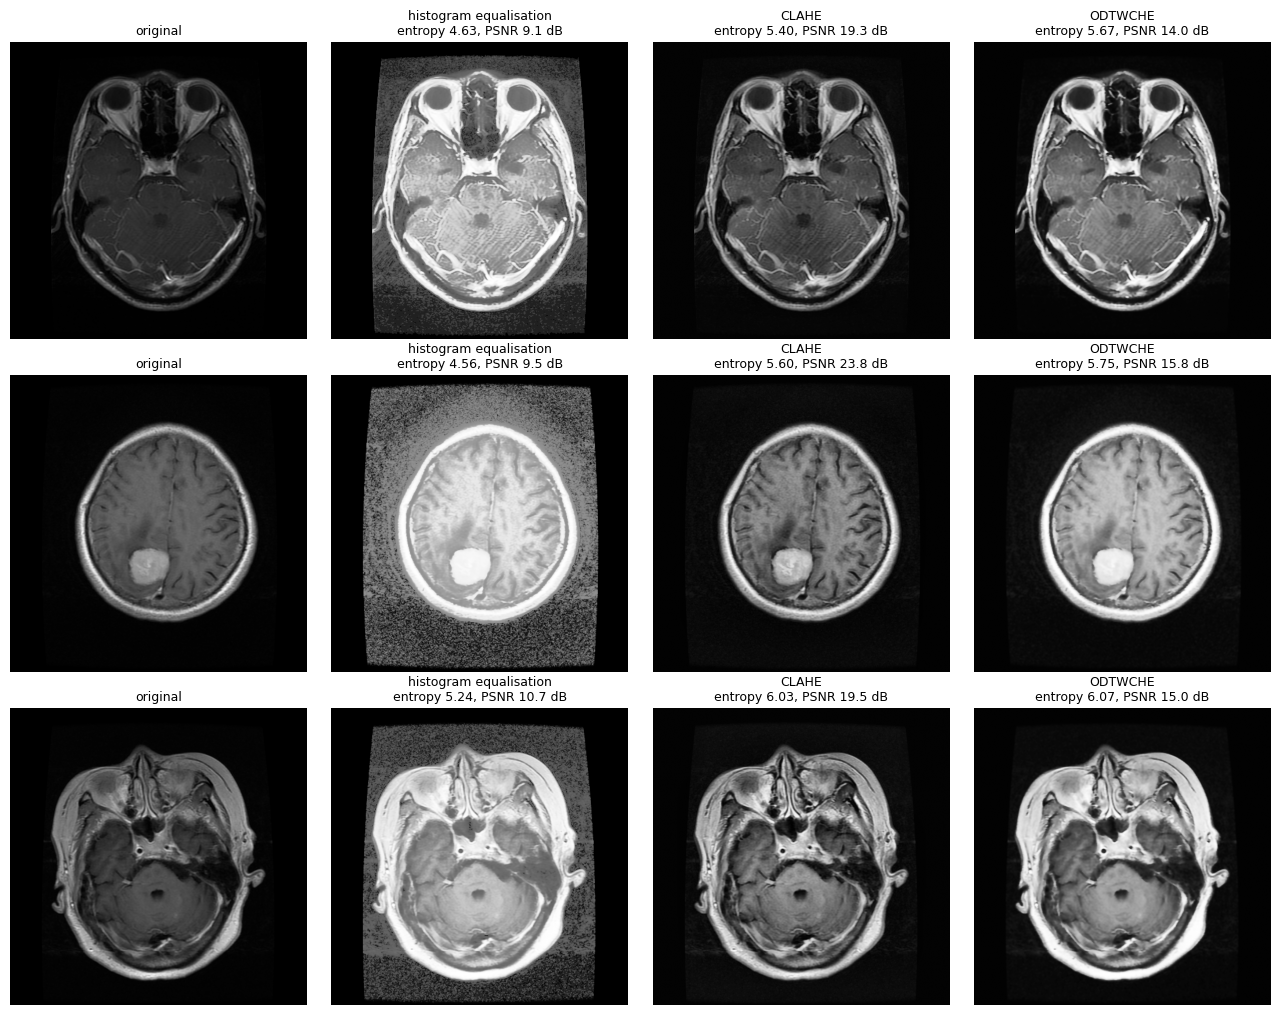

In [3]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
files = data.groupby("tumor_type").sample(1, random_state=1).file
fig, axes = plt.subplots(len(files), 4, figsize=(13, 3.4 * len(files)))
for r, f in enumerate(files):
    im = cv2.imread(str(C.IMAGES_DIR / f), 0)
    results = {"original": im, "histogram equalisation": cv2.equalizeHist(im),
               "CLAHE": clahe.apply(im), "ODTWCHE": odtwche(im)}
    for c, (name, out) in enumerate(results.items()):
        axes[r, c].imshow(out, cmap="gray")
        title = name if name == "original" else f"{name}\nentropy {entropy(histogram(out)):.2f}, PSNR {psnr(im, out):.1f} dB"
        axes[r, c].set_title(title, fontsize=9)
        axes[r, c].axis("off")
plt.tight_layout()
plt.savefig(C.RESULTS_DIR / "method_comparison.png", dpi=100)

* **Entropy** = amount of detail (higher is better)
* **PSNR** = how close the result stays to the original (higher = fewer artefacts)

Plain histogram equalisation over-enhances (low PSNR). ODTWCHE aims for more detail without artefacts.

## Enhance all images in our subset → `data/enhanced/`

In [4]:
enhance_dataset(data.file)

  0%|          | 0/603 [00:00<?, ?it/s]

  0%|          | 2/603 [00:00<01:03,  9.51it/s]

  0%|          | 3/603 [00:00<01:05,  9.13it/s]

  1%|          | 4/603 [00:00<01:05,  9.15it/s]

  1%|          | 5/603 [00:00<01:06,  9.04it/s]

...

100%|█████████▉| 600/603 [01:07<00:00,  8.27it/s]

100%|█████████▉| 601/603 [01:07<00:00,  8.18it/s]

100%|█████████▉| 602/603 [01:07<00:00,  8.44it/s]

100%|██████████| 603/603 [01:07<00:00,  8.54it/s]

100%|██████████| 603/603 [01:07<00:00,  8.91it/s]